In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from ucimlrepo import fetch_ucirepo 

In [2]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
df = pd.concat([X, y], axis=1)


In [11]:
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

In [12]:
print("Class Distribution (0: Benign, 1: Malignant):")
print(df['Diagnosis'].value_counts())

Class Distribution (0: Benign, 1: Malignant):
Diagnosis
0    357
1    212
Name: count, dtype: int64


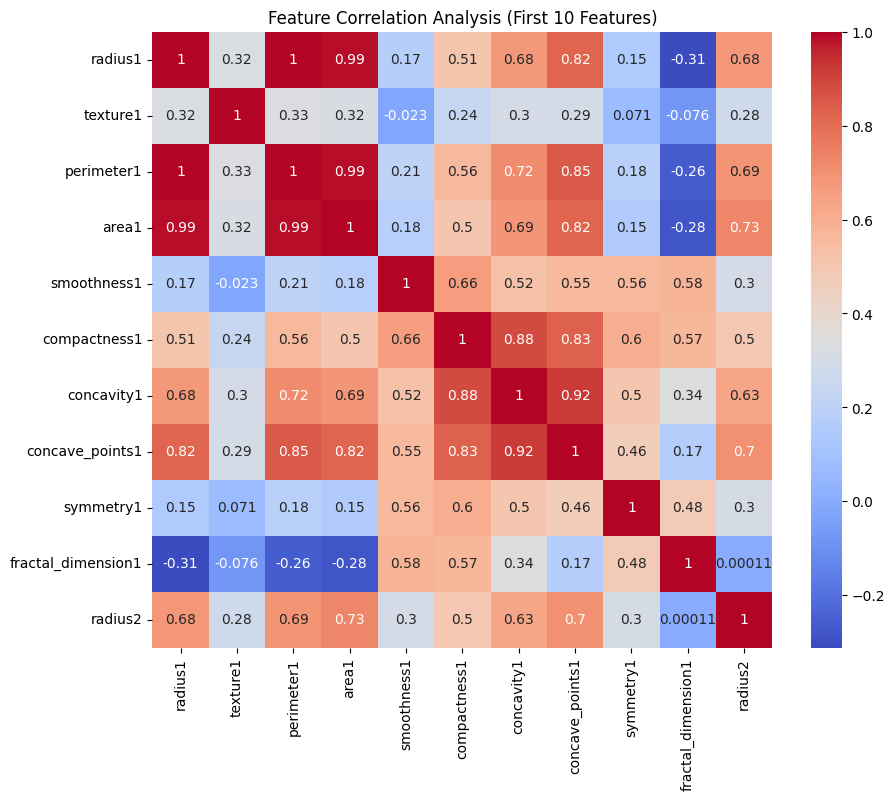

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :11].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Analysis (First 10 Features)")
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [28]:
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [29]:
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5,scoring=['accuracy', 'f1'],refit='accuracy')
dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [30]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5,scoring=['accuracy', 'f1'],refit='accuracy')
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [31]:
print("\nTable 1: Decision Tree Hyperparameter Evaluation (Top 5 Results)")
dt_results = pd.DataFrame(dt_grid.cv_results_)
# Extract both accuracy and f1 mean test scores
dt_table = dt_results[['param_criterion', 'param_max_depth', 'mean_test_accuracy', 'mean_test_f1']].sort_values(by='mean_test_accuracy', ascending=False).head(5)
# Rename to exactly match the lab manual
dt_table.columns = ['Criterion', 'Max Depth', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']
# Convert accuracy and F1 to percentages for better readability (optional, but matches the '%' in header)
dt_table['Avg CV Accuracy (%)'] = (dt_table['Avg CV Accuracy (%)'] * 100).round(2)
dt_table['Avg CV F1 Score'] = (dt_table['Avg CV F1 Score'] * 100).round(2)
print(dt_table)


Table 1: Decision Tree Hyperparameter Evaluation (Top 5 Results)
   Criterion Max Depth  Avg CV Accuracy (%)  Avg CV F1 Score
40   entropy         3                94.29            92.32
47   entropy         5                94.29            92.06
50   entropy         5                94.29            92.06
56   entropy        10                94.29            92.06
65   entropy      None                94.29            92.06


In [32]:
print("\nTable 2: Random Forest Hyperparameter Evaluation (Top 5 Results)")
rf_results = pd.DataFrame(rf_grid.cv_results_)
# Extract both accuracy and f1 mean test scores
rf_table = rf_results[['param_n_estimators', 'param_max_depth', 'param_max_features', 'mean_test_accuracy', 'mean_test_f1']].sort_values(by='mean_test_accuracy', ascending=False).head(5)
# Rename to exactly match the lab manual
rf_table.columns = ['n_estimators', 'Max Depth', 'Max Features', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']
# Convert accuracy and F1 to percentages
rf_table['Avg CV Accuracy (%)'] = (rf_table['Avg CV Accuracy (%)'] * 100).round(2)
rf_table['Avg CV F1 Score'] = (rf_table['Avg CV F1 Score'] * 100).round(2)
print(rf_table)


Table 2: Random Forest Hyperparameter Evaluation (Top 5 Results)
    n_estimators Max Depth Max Features  Avg CV Accuracy (%)  Avg CV F1 Score
24            50        10         sqrt                96.48            95.15
30            50        20         sqrt                96.48            95.15
18            50      None         sqrt                96.48            95.15
2            200      None         sqrt                96.26            94.88
22           100      None         log2                96.26            94.92


In [21]:
cv_dt = cross_validate(dt_grid.best_estimator_, X_train, y_train, cv=5)['test_score']
cv_rf = cross_validate(rf_grid.best_estimator_, X_train, y_train, cv=5)['test_score']

In [23]:
cv_dt = cross_validate(dt_grid.best_estimator_, X_train, y_train, cv=5)['test_score']
cv_rf = cross_validate(rf_grid.best_estimator_, X_train, y_train, cv=5)['test_score']

# Create the data as a list of dictionaries to avoid index length errors
comparison_data = [
    {
        'Model': 'Decision Tree',
        'Fold 1': cv_dt[0], 'Fold 2': cv_dt[1], 'Fold 3': cv_dt[2], 
        'Fold 4': cv_dt[3], 'Fold 5': cv_dt[4], 'Average': np.mean(cv_dt)
    },
    {
        'Model': 'Random Forest',
        'Fold 1': cv_rf[0], 'Fold 2': cv_rf[1], 'Fold 3': cv_rf[2], 
        'Fold 4': cv_rf[3], 'Fold 5': cv_rf[4], 'Average': np.mean(cv_rf)
    }
]

cv_comparison = pd.DataFrame(comparison_data)

print("\nTable 3: 5-Fold Cross-Validation Accuracy Comparison")
print(cv_comparison)


Table 3: 5-Fold Cross-Validation Accuracy Comparison
           Model    Fold 1    Fold 2    Fold 3    Fold 4    Fold 5   Average
0  Decision Tree  0.978022  0.912088  0.945055  0.945055  0.934066  0.942857
1  Random Forest  0.978022  0.956044  0.967033  0.978022  0.945055  0.964835



--- Decision Tree Performance ---
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9070
F1-Score:  0.9512
Confusion Matrix:
[[71  0]
 [ 4 39]]

--- Random Forest Performance ---
Accuracy:  0.9561
Precision: 0.9524
Recall:    0.9302
F1-Score:  0.9412
Confusion Matrix:
[[69  2]
 [ 3 40]]


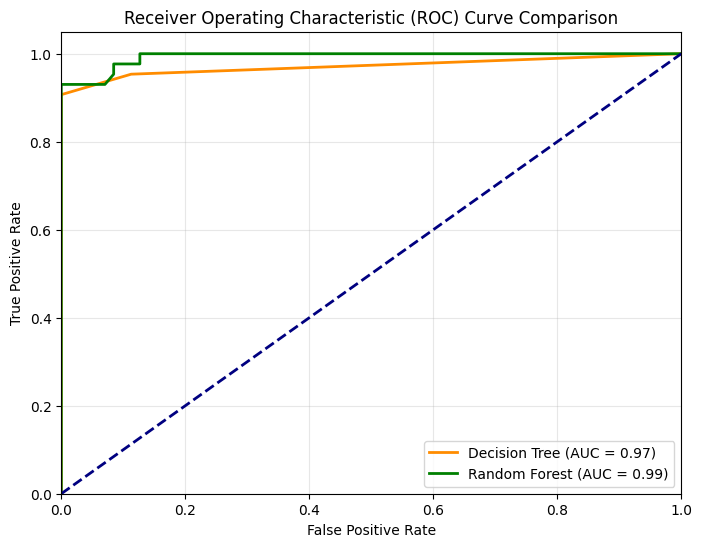

In [27]:
# --- Evaluation Metrics Implementation ---
def display_metrics(model, name):
    y_pred = model.predict(X_test)
    # Probability estimates for ROC Curve
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n--- {name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}") 
    print(f"Precision: {precision_score(y_test, y_pred):.4f}") 
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}") 
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}") 
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cm}")
    
    # ROC Curve and AUC calculation
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Calculate metrics for both models
fpr_dt, tpr_dt, auc_dt = display_metrics(dt_grid.best_estimator_, "Decision Tree")
fpr_rf, tpr_rf, auc_rf = display_metrics(rf_grid.best_estimator_, "Random Forest")

# Plotting ROC Curve Comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()